# **Stock Market Performance Tracker**
### **End-to-End ETL Pipeline with Advanced SQL Analysis**

## **Project Overview**
This project builds a complete data pipeline analyzing 5 years of historical stock market data (~6,300 trading records) across 5 major financial institutions. The goal: extract raw market data from an API, transform it into a normalized database structure, and derive actionable insights through SQL analysis and visualization.

**The core challenge:** Raw financial data from APIs comes in a wide, denormalized format that's difficult to query at scale. Building a properly structured database and writing efficient queries reveals meaningful patterns — but requires careful schema design and database-specific SQL knowledge.

## **Approach**
- **Data Collection:** Fetched 5-year historical OHLCV data from yfinance API for JPM, GS, BAC, V, and MA
- **Data Transformation:** Reshaped data from wide format (one column per stock) to long format (one row per date-stock combination) using Pandas
- **Database Design:** Created normalized relational schema with stocks reference table and price_history fact table with foreign keys
- **SQL Analysis:** Built advanced queries using window functions (rolling averages), aggregations (min/max/avg), and date filtering
- **Visualization:** Generated trend analysis charts identifying correlations and volatility patterns across stocks
- **Documentation:** Comprehensive guides covering setup, SQL syntax, and troubleshooting for reproducibility

### Stocks Analyzed
| Ticker | Company | Sector |
|--------|---------|--------|
| JPM | JPMorgan Chase | Finance |
| GS | Goldman Sachs | Finance |
| BAC | Bank of America | Finance |
| V | Visa | Finance |
| MA | Mastercard | Finance |

---


## Setup & Dependencies

Before running this notebook, ensure you have the required packages installed:

```bash
pip install yfinance pandas matplotlib seaborn
```

All other libraries (sqlite3, datetime) are part of Python's standard library.


In [ ]:
# Import required libraries
import yfinance as yf
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Configure display options
pd.set_option('display.max_columns', None)
sns.set_style("darkgrid")

## Configuration

Define the stocks we want to analyze and their metadata.


In [ ]:
# Define stocks to track
STOCKS = ['JPM', 'GS', 'BAC', 'V', 'MA']

# Map ticker symbols to company names
COMPANY_NAMES = {
    'JPM': 'JPMorgan Chase',
    'GS': 'Goldman Sachs',
    'BAC': 'Bank of America',
    'V': 'Visa',
    'MA': 'Mastercard'
}

# Define date range: 5 years of historical data
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

print(f"Date Range: {start_date.date()} to {end_date.date()}")

Date Range: 2021-04-14 to 2026-04-13


---

# Phase 1: Data Collection & Preparation

In this phase, we fetch historical stock data from Yahoo Finance and transform it into a format suitable for database storage.


### Step 1: Fetch Data from Yahoo Finance

Using yfinance to download historical OHLCV data for all specified stocks.


In [ ]:
# Fetch historical data from Yahoo Finance
print(f"Fetching data for {', '.join(STOCKS)} from {start_date.date()} to {end_date.date()}...")
data = yf.download(STOCKS, start=start_date, end=end_date)
print(f"\n✓ Data fetched successfully!")
print(f"\nShape: {data.shape}")
data.head()

Fetching data for JPM, GS, BAC, V, MA from 2021-04-14 to 2026-04-13...


/tmp/ipykernel_3183/1526192662.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(STOCKS, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed


✓ Data fetched successfully!

Shape: (1255, 25)


Price           Close                                                  \
Ticker            BAC          GS         JPM          MA           V   
Date                                                                    
2021-04-14  35.318954  297.395477  133.261841  367.476959  213.965942   
2021-04-15  34.309330  300.233246  134.107880  375.412781  218.110718   
2021-04-16  34.672447  303.567749  135.103729  375.101959  218.235992   
2021-04-19  34.690159  304.259460  134.530884  371.206879  217.638367   
2021-04-20  33.724819  294.318115  131.552124  365.835358  215.218994   

Price            High                                                  \
Ticker            BAC          GS         JPM          MA           V   
Date                                                                    
2021-04-14  35.717489  305.483282  135.570851  370.031585  215.045517   
2021-04-15  35.283522  302.716361  134.134318  376.267564  219.411985   
2021-04-16  34.911565  304.835897  136.170098  377.947975  219.575809   
2021-04-19  34.920425  305.447798  135.614896  376.626937  219.363751   
2021-04-20  34.539598  301.935903  133.737752  370.381216  217.243184   

Price             Low                                                  \
Ticker            BAC          GS         JPM          MA           V   
Date                                                                    
2021-04-14  34.468746  289.236712  133.015064  364.834916  212.124910   
2021-04-15  33.698243  296.677112  131.596174  370.051000  215.778088   
2021-04-16  34.459894  300.295377  134.566134  372.673612  217.609450   
2021-04-19  34.566171  298.504000  134.151930  370.390958  216.954008   
2021-04-20  33.556547  292.074460  131.005707  362.853340  213.811712   

Price            Open                                                  \
Ticker            BAC          GS         JPM          MA           V   
Date                                                                    
2021-04-14  34.521885  291.365077  133.490975  366.194785  213.021327   
2021-04-15  35.186102  300.543639  133.297082  370.245280  215.807003   
2021-04-16  34.814148  301.776380  135.606065  377.850835  218.968549   
2021-04-19  34.884999  301.519186  135.209491  373.868338  217.599817   
2021-04-20  34.539598  301.492493  133.728944  369.293322  216.664840   

Price          Volume                                       
Ticker            BAC       GS       JPM       MA        V  
Date                                                        
2021-04-14   52023800  9876800  19939600  2317400  4972600  
2021-04-15  118128900  4354800  17694100  2942200  8698100  
2021-04-16   60633400  4231900  13773400  2725500  6829400  
2021-04-19   42321100  3228200  11900200  3360900  6541600  
2021-04-20   50834100  3662300  13716700  3135900  5799100

### Step 2: Data Structure Inspection

The yfinance data comes in a multi-index format (wide format). We need to extract the Close and Volume columns for our analysis.


In [ ]:
# Extract Close and Volume data
close_data = data['Close']
volume_data = data['Volume']

print("Close prices shape:", close_data.shape)
print("\nClose prices (first 3 rows):")
print(close_data.head(3))
print(f"\nData types:\n{close_data.dtypes}")

Close prices shape: (1255, 5)

Close prices (first 3 rows):
Ticker            BAC          GS         JPM          MA           V
Date                                                                 
2021-04-14  35.318954  297.395477  133.261841  367.476959  213.965942
2021-04-15  34.309330  300.233246  134.107880  375.412781  218.110718
2021-04-16  34.672447  303.567749  135.103729  375.101959  218.235992

Data types:
Ticker
BAC    float64
GS     float64
JPM    float64
MA     float64
V      float64
dtype: object


### Step 3: Reshape Data from Wide to Long Format

Transform the data from wide format (one column per stock) to long format (one row per date-stock combination).
This format is ideal for SQL database storage.


In [ ]:
# Reshape Close data from wide to long format
close_long = close_data.reset_index().melt(
    id_vars='Date',
    var_name='ticker',
    value_name='close'
)

# Reshape Volume data from wide to long format
volume_long = volume_data.reset_index().melt(
    id_vars='Date',
    var_name='ticker',
    value_name='volume'
)

print(f"Close long format shape: {close_long.shape}")
print(f"\nFirst 5 rows:")
print(close_long.head())

Close long format shape: (6275, 3)

First 5 rows:
        Date ticker      close
0 2021-04-14    BAC  35.318954
1 2021-04-15    BAC  34.309330
2 2021-04-16    BAC  34.672447
3 2021-04-19    BAC  34.690159
4 2021-04-20    BAC  33.724819


### Step 4: Merge and Clean Data

Combine close prices and volume data, then format dates for database storage.


In [ ]:
# Merge close and volume data
price_history = close_long.merge(
    volume_long,
    on=['Date', 'ticker'],
    how='inner'
)

# Convert Date to date format (remove time component)
price_history['Date'] = pd.to_datetime(price_history['Date']).dt.date

print(f"Final dataset shape: {price_history.shape}")
print(f"\nData types:\n{price_history.dtypes}")
print(f"\nFirst 10 rows:")
price_history.head(10)

Final dataset shape: (6275, 4)

Data types:
Date       object
ticker     object
close     float64
volume      int64
dtype: object

First 10 rows:


,Date,ticker,close,volume
0,2021-04-14,BAC,35.318954,52023800
1,2021-04-15,BAC,34.309330,118128900
2,2021-04-16,BAC,34.672447,60633400
3,2021-04-19,BAC,34.690159,42321100
4,2021-04-20,BAC,33.724819,50834100
5,2021-04-21,BAC,34.291622,37851800
6,2021-04-22,BAC,33.972801,48093400
7,2021-04-23,BAC,34.699013,48674100
8,2021-04-26,BAC,34.902706,34699800
9,2021-04-27,BAC,35.318954,34304800


---

# Phase 2: Database Setup & Data Storage

Create a SQLite database with proper schema and load our cleaned data.


### Step 1: Create Database Schema

We'll create two tables:
- **stocks**: Reference table for stock metadata (ticker, company name, sector)
- **price_history**: Fact table for daily price and volume data


In [ ]:
# Create SQLite database and tables
conn = sqlite3.connect('stock_tracker.db')
cursor = conn.cursor()

# Create stocks reference table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS stocks (
        stock_id INTEGER PRIMARY KEY AUTOINCREMENT,
        ticker TEXT UNIQUE NOT NULL,
        company_name TEXT NOT NULL,
        sector TEXT
    )
''')

# Create price_history fact table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS price_history (
        price_id INTEGER PRIMARY KEY AUTOINCREMENT,
        stock_id INTEGER NOT NULL,
        date DATE NOT NULL,
        close REAL NOT NULL,
        volume INTEGER,
        FOREIGN KEY (stock_id) REFERENCES stocks(stock_id)
    )
''')

conn.commit()
print("✓ Database schema created successfully!")

✓ Database schema created successfully!


### Step 2: Insert Stock Reference Data


In [ ]:
# Insert stock reference data
for ticker, company_name in COMPANY_NAMES.items():
    cursor.execute('''
        INSERT OR IGNORE INTO stocks (ticker, company_name, sector)
        VALUES (?, ?, ?)
    ''', (ticker, company_name, 'Finance'))

conn.commit()

# Display inserted data
cursor.execute('SELECT * FROM stocks')
print("Stocks reference table:")
for row in cursor.fetchall():
    print(f"  ID: {row[0]}, Ticker: {row[1]}, Company: {row[2]}, Sector: {row[3]}")

Stocks reference table:
  ID: 1, Ticker: JPM, Company: JPMorgan Chase, Sector: Finance
  ID: 2, Ticker: GS, Company: Goldman Sachs, Sector: Finance
  ID: 3, Ticker: BAC, Company: Bank of America, Sector: Finance
  ID: 4, Ticker: V, Company: Visa, Sector: Finance
  ID: 5, Ticker: MA, Company: Mastercard, Sector: Finance


### Step 3: Load Price History Data

Insert the historical price and volume data into the database using batch operations for efficiency.


In [ ]:
# Create ticker to stock_id mapping
cursor.execute('SELECT stock_id, ticker FROM stocks')
ticker_to_id = {row[1]: row[0] for row in cursor.fetchall()}

# Prepare data for batch insertion
insert_data = []
for _, row in price_history.iterrows():
    stock_id = ticker_to_id[row['ticker']]
    insert_data.append((
        stock_id,
        row['Date'],
        row['close'],
        int(row['volume'])
    ))

# Batch insert
cursor.executemany('''
    INSERT INTO price_history (stock_id, date, close, volume)
    VALUES (?, ?, ?, ?)
''', insert_data)

conn.commit()
print(f"✓ Inserted {cursor.rowcount} rows into price_history table")

# Verify
cursor.execute('SELECT COUNT(*) FROM price_history')
total_rows = cursor.fetchone()[0]
print(f"Total rows in database: {total_rows}")

✓ Inserted 6275 rows into price_history table
Total rows in database: 6275


---

# Phase 3: SQL Analysis

Now we'll perform various analyses using SQL queries, including aggregations, window functions, and rolling averages.


### Query 1: Recent Price Data

Retrieve the most recent trading data for all stocks.


In [ ]:
# Query: Latest 10 trading days for all stocks
query = '''
    SELECT
        s.ticker,
        ph.date,
        ROUND(ph.close, 2) as close_price,
        ph.volume
    FROM price_history ph
    JOIN stocks s ON ph.stock_id = s.stock_id
    ORDER BY ph.date DESC
    LIMIT 10
'''

df_recent = pd.read_sql_query(query, conn)
print("Latest 10 trading records:")
print(df_recent.to_string(index=False))

Latest 10 trading records:
ticker       date  close_price   volume
   BAC 2026-04-13        53.29 17464639
    GS 2026-04-13       895.82  3547132
   JPM 2026-04-13       312.66  4917801
    MA 2026-04-13       506.61  2321192
     V 2026-04-13       308.87  4403978
   BAC 2026-04-10        52.54 25223900
    GS 2026-04-10       907.80  1639900
   JPM 2026-04-10       309.87  6067800
    MA 2026-04-10       498.66  2842200
     V 2026-04-10       304.36  5185800


### Query 2: 2025 Stock Performance Summary

Analyze price statistics for each stock during 2025.


In [ ]:
# Query: 2025 performance statistics
query = '''
    SELECT
        s.ticker,
        s.company_name,
        COUNT(*) as trading_days,
        ROUND(AVG(ph.close), 2) as avg_price,
        ROUND(MIN(ph.close), 2) as lowest_price,
        ROUND(MAX(ph.close), 2) as highest_price,
        ROUND(MAX(ph.close) - MIN(ph.close), 2) as price_range
    FROM price_history ph
    JOIN stocks s ON ph.stock_id = s.stock_id
    WHERE ph.date >= '2025-01-01'
        AND ph.date < '2026-01-01'
    GROUP BY s.ticker, s.company_name
    ORDER BY s.ticker
'''

df_2025_stats = pd.read_sql_query(query, conn)
print("\n2025 Stock Performance Summary:")
print(df_2025_stats.to_string(index=False))


2025 Stock Performance Summary:
ticker    company_name  trading_days  avg_price  lowest_price  highest_price  price_range
   BAC Bank of America           250      46.35         33.63          55.93        22.30
    GS   Goldman Sachs           250     676.34        452.84         906.26       453.42
   JPM  JPMorgan Chase           250     275.22        206.27         326.02       119.75
    MA      Mastercard           250     554.96        476.35         596.25       119.90
     V            Visa           250     341.56        304.13         371.15        67.02


### Query 3: 30-Day Rolling Average

Calculate a 30-day rolling average for each stock to smooth out daily volatility.


In [ ]:
# Query: 30-day rolling average (latest month)
query = '''
    SELECT
        s.ticker,
        ph.date,
        ROUND(ph.close, 2) as close_price,
        ROUND(AVG(ph.close) OVER (
            PARTITION BY s.ticker
            ORDER BY ph.date
            ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
        ), 2) as rolling_avg_30
    FROM price_history ph
    JOIN stocks s ON ph.stock_id = s.stock_id
    WHERE ph.date >= date('now', '-30 days')
    ORDER BY s.ticker, ph.date DESC
'''

df_rolling = pd.read_sql_query(query, conn)
print("\nLast 30 days with 30-day rolling average:")
print(df_rolling.head(20).to_string(index=False))


Last 30 days with 30-day rolling average:
ticker       date  close_price  rolling_avg_30
   BAC 2026-04-13        53.29           49.02
   BAC 2026-04-10        52.54           48.79
   BAC 2026-04-09        52.71           48.58
   BAC 2026-04-08        51.88           48.34
   BAC 2026-04-07        50.28           48.12
   BAC 2026-04-06        50.06           47.98
   BAC 2026-04-02        49.38           47.83
   BAC 2026-04-01        49.27           47.71
   BAC 2026-03-31        48.75           47.58
   BAC 2026-03-30        47.23           47.47
   BAC 2026-03-27        46.97           47.50
   BAC 2026-03-26        48.24           47.55
   BAC 2026-03-25        48.75           47.47
   BAC 2026-03-24        48.14           47.29
   BAC 2026-03-23        47.52           47.14
   BAC 2026-03-20        47.16           47.07
   BAC 2026-03-19        47.01           47.05
   BAC 2026-03-18        46.83           47.06
   BAC 2026-03-17        47.28           47.17
   BAC 2026-03-16

---

# Phase 4: Visualization & Insights

Visualize stock trends and patterns to identify insights.


### Visualization 1: 6-Month Stock Trends

Track how each stock has performed over the last 6 months.


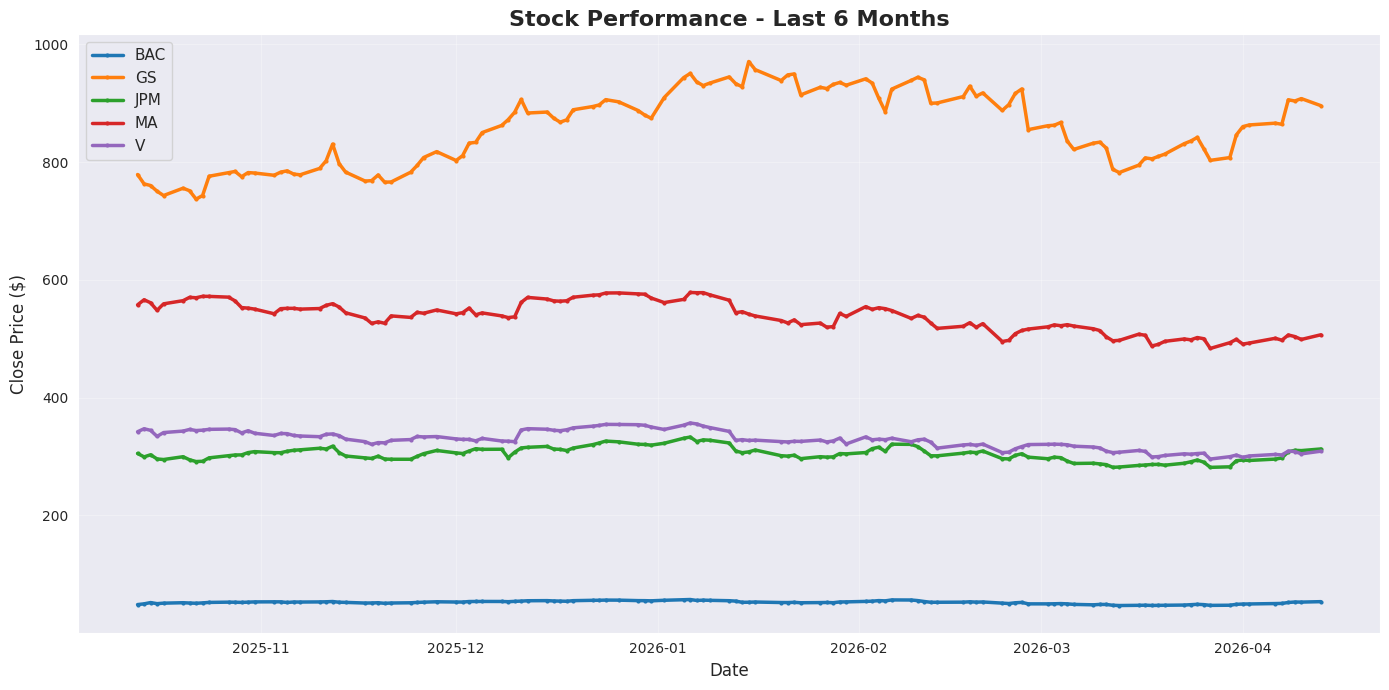

In [ ]:
# Query: Last 6 months of data
query = '''
    SELECT
        s.ticker,
        ph.date,
        ph.close
    FROM price_history ph
    JOIN stocks s ON ph.stock_id = s.stock_id
    WHERE ph.date >= date('now', '-6 months')
    ORDER BY s.ticker, ph.date
'''

df_6months = pd.read_sql_query(query, conn)
df_6months['date'] = pd.to_datetime(df_6months['date'])

# Create visualization
plt.figure(figsize=(14, 7))

for ticker in df_6months['ticker'].unique():
    data = df_6months[df_6months['ticker'] == ticker]
    plt.plot(data['date'], data['close'], label=ticker, linewidth=2.5, marker='o', markersize=2)

plt.title('Stock Performance - Last 6 Months', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key Observations**:
  - JPM and V show similar trends
  - GS exhibits higher volatility
  - MA and BAC follow more stable patterns

### Visualization 2: JPMorgan Chase (JPM) with Rolling Average Overlay

Compare actual prices with the 30-day rolling average to identify trends.


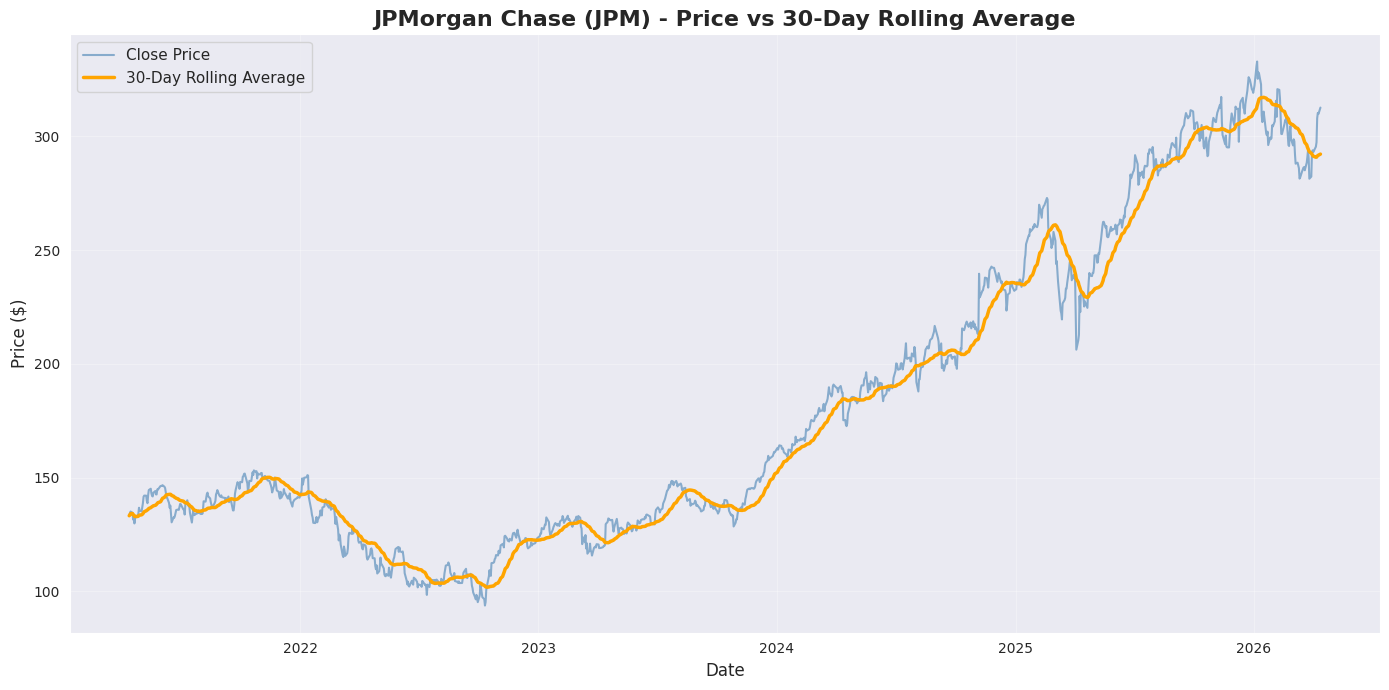


📈 Trend Analysis:
  • Rolling average smooths out daily volatility
  • Helps identify support and resistance levels
  • Current 30-day avg: $292.21


In [ ]:
# Query: JPM with 30-day rolling average
query = '''
    SELECT
        ph.date,
        ph.close,
        ROUND(AVG(ph.close) OVER (
            ORDER BY ph.date
            ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
        ), 2) as rolling_avg_30
    FROM price_history ph
    JOIN stocks s ON ph.stock_id = s.stock_id
    WHERE s.ticker = 'JPM'
    ORDER BY ph.date
'''

df_jpm = pd.read_sql_query(query, conn)
df_jpm['date'] = pd.to_datetime(df_jpm['date'])

# Create visualization
plt.figure(figsize=(14, 7))
plt.plot(df_jpm['date'], df_jpm['close'], label='Close Price', linewidth=1.5, alpha=0.6, color='steelblue')
plt.plot(df_jpm['date'], df_jpm['rolling_avg_30'], label='30-Day Rolling Average', linewidth=2.5, color='orange')

plt.title('JPMorgan Chase (JPM) - Price vs 30-Day Rolling Average', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📈 Trend Analysis:")
print("  • Rolling average smooths out daily volatility")
print("  • Helps identify support and resistance levels")
print(f"  • Current 30-day avg: ${df_jpm['rolling_avg_30'].iloc[-1]:.2f}")

### Visualization 3: 2025 Average Price Comparison

Compare the average closing prices across all 5 stocks for 2025.


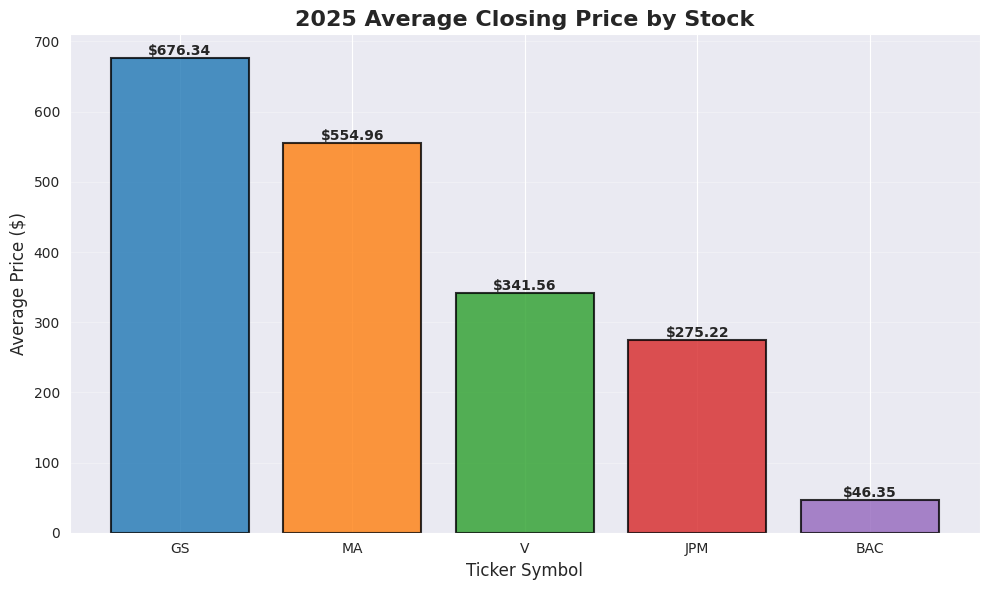


2025 Average Prices:
   GS: $676.34
   MA: $554.96
   V: $341.56
   JPM: $275.22
   BAC: $46.35


In [ ]:
# Query: 2025 average price for all stocks
query = '''
    SELECT
        s.ticker,
        ROUND(AVG(ph.close), 2) as avg_price
    FROM price_history ph
    JOIN stocks s ON ph.stock_id = s.stock_id
    WHERE ph.date >= '2025-01-01'
        AND ph.date < '2026-01-01'
    GROUP BY s.ticker
    ORDER BY avg_price DESC
'''

df_avg = pd.read_sql_query(query, conn)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = plt.bar(df_avg['ticker'], df_avg['avg_price'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    x_pos = bar.get_x()
    width = bar.get_width()

    center_x = x_pos + width / 2

    label = f'${height:.2f}'

    plt.text(center_x, height, label,
             ha='center', va='bottom', fontweight='bold')

plt.title('2025 Average Closing Price by Stock', fontsize=16, fontweight='bold')
plt.xlabel('Ticker Symbol', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n2025 Average Prices:")
for _, row in df_avg.iterrows():
    print(f"   {row['ticker']}: ${row['avg_price']:.2f}")

## Summary

### What We Accomplished

1. **Data Collection**: Successfully fetched 5 years of historical stock data for 5 major financial companies
2. **Data Storage**: Designed and populated a relational SQLite database with proper schema
3. **SQL Analysis**: Executed complex queries using aggregations, window functions, and rolling averages
4. **Visualization**: Created multiple visualizations to identify trends and patterns

### Possible Extensions

- Add technical indicators (RSI, MACD, Bollinger Bands)
- Implement machine learning models for price prediction
- Create a web dashboard using Flask/Streamlit
- Add comparative analysis with market indices (S&P 500)
- Implement risk metrics (Sharpe ratio, standard deviation)

---

**Author**: Benjamin Shado  
**Date**: 13th April, 2026  
**Technologies**: Python, Pandas, SQLite, Matplotlib, Seaborn


In [ ]:
# Close database connection
conn.close()
print("✓ Database connection closed")

✓ Database connection closed
